In [ ]:
# -*- coding: utf-8 -*-
"""
Word (.docx) içinden:
- Ana bölüm (TEBLİĞ / EK-1 / EK-2 / EK-3)
- Alt başlık (bold paragraf)
- MADDE no
- MADDE metni  (bir sonraki madde/başlık/ana bölüm gelene kadar)

çıkarıp pandas DataFrame olarak verir.
"""

from docx import Document
import re
import pandas as pd

# ======= KULLANICI AYARLARI =======
DOCX_PATH = "IDD Teblig_New.docx"  # dosya adını gerekirse değiştir
SAVE_EXCEL = True                  # Excel çıktı istiyorsan True
EXCEL_PATH = "maddeler.xlsx"

# Ana bloklar: dokümanda birebir geçen başlıkları yaz
ANA_BOLUMLER = [
    "TEMEL KREDİ RİSKİNE ESAS TUTARIN İÇSEL DERECELENDİRMEYE DAYALI YAKLAŞIMLAR İLE HESAPLANMASINA İLİŞKİN TEBLİĞ",
    "EK-1",
    "EK-2",
    "EK-3",
]

# "MADDE 1 -", "MADDE 2 –", "MADDE 3:" vb. yakalayan regex
RE_MADDE_BASI = re.compile(r"^\s*MADDE\s+([0-9]+)\s*[-–—:]?\s*(.*)$", re.IGNORECASE)

# (İsteğe bağlı) "BİRİNCİ BÖLÜM" gibi bölüm başlarını atlamak istersen:
RE_BOLUM_SATIRI = re.compile(r"^\s*(BİRİNCI|İKİNCİ|ÜÇÜNCÜ|DÖRDÜNCÜ|BEŞİNCİ|ALTINCI|YEDİNCİ|SEKİZİNCİ|DOKUZUNCU|ONUNCU)\s+BÖLÜM", re.IGNORECASE)


def is_bold_paragraph(p):
    """Paragrafın herhangi bir run'ı bold ise True (ve içinde gerçek metin var)."""
    return any(r.text.strip() and (r.bold is True) for r in p.runs)


def parse_docx(docx_path: str):
    doc = Document(docx_path)

    ana_bolum = None
    alt_baslik = None
    rows = []
    current_madde = None  # {"ana_bolum","alt_baslik","madde_no","madde_metni"}

    def flush_current():
        """Aktif maddeyi rows'a at."""
        nonlocal current_madde
        if current_madde:
            # Metni trime et, gereksiz çoklu boşlukları sadeleştir (satır sonları kalsın)
            metin = current_madde.get("madde_metni", "").strip()
            if metin:
                current_madde["madde_metni"] = metin
                rows.append(current_madde)
        current_madde = None

    paragraphs = doc.paragraphs
    for p in paragraphs:
        text = (p.text or "").strip()

        # --- boş satırlar: aktif madde içinde satır sonu olarak ekle ---
        if not text:
            if current_madde is not None:
                current_madde["madde_metni"] += "\n"
            continue

        # --- Ana bölüm değişimi? ---
        if any(text.startswith(b) for b in ANA_BOLUMLER):
            flush_current()
            ana_bolum = text
            alt_baslik = None
            continue

        # --- "BİRİNCİ BÖLÜM" vb. bölüm satırları (varsa) → içeriğe girmesin ---
        if RE_BOLUM_SATIRI.match(text):
            flush_current()
            # alt_baslik aynı kalsın; bu sadece görsel bölüm başı
            continue

        # --- Bold alt başlık mı? (örn. "Amaç ve kapsam", "Dayanak", "Tanımlar"...) ---
        # Not: "MADDE x" satırı da bold olabilir; o yüzden önce MADDE’yi kontrol edeceğiz (aşağıda).
        if is_bold_paragraph(p) and not RE_MADDE_BASI.match(text):
            flush_current()
            alt_baslik = text
            continue

        # --- MADDE başlangıcı mı? ---
        m = RE_MADDE_BASI.match(text)
        if m:
            # Önceki maddeyi kapat
            flush_current()
            madde_no = m.group(1)
            ilk_satir = m.group(2).strip()  # Aynı satırda metin varsa
            current_ma_


In [ ]:
# Senatör Featureunda yapmak istediğim:
# Senatörlerin rankingini sağlamak bu 2 farklı yolun birleşmesiyle olucak
# Biri senator trust index diyebiliriz bu geçmişe yönelik işlemlerde
# Bunda 2 spektrum yaparız buy farklı sell farklı olur 
# Transaction date ve received datedeki fiyatları karşılaştıracak
# Bu sayede aradaki sürede fiyat farkı az mı olmuş uzun vadeli mi
# Kısa vadeli mi yatırım yapıyor görüyor olacağız
# İkincisi senatör performans endeksi backtestle beraber
# Bir nevi senatörlerin performanslarını yorumlayacağız
# Bu elde ettiğimiz rankingi kullanacğımız bir faz olucak
# Ekonomik metriklerle sıraladığımız ve belli bir değerin üstünü yatırım
# için değerlendirmeye geçmeden yakın zamanda senatörler kendi
# rating katsayılarıyla beraber buy pozitif etki edicek
# sell negatif etki edicek sonrasında yine ranking hisselerimiz olacak

# Ayrıca yapılacaklar: 
# Otomatik power bi raporları
# JupyterHUBA geçiş ya da benzeri
# Trade box enjeksityonu
# Zipline a bak https://zipline.ml4trading.io



In [3]:
# https://github.com/AliHabibnia/Algorithmic_Trading_with_Python/blob/main/Lecture%2000_Introduction%20to%20Algorithmic%20Trading.ipynb
import yfinance as yf
import mplfinance as mpf
import datetime as dt
import pandas_ta as ta

start_date = dt.datetime(2024, 1, 1)
end_date = dt.datetime.now()
stock_symbol = "NVDA"

data = yf.download(stock_symbol, start=start_date, end=end_date)

mpf.plot(data, type='candle', style='yahoo', title=f"{stock_symbol}", volume=True, figsize=(15,10))

[*********************100%***********************]  1 of 1 completed


ValueError: Data for column "Open" must be ALL float or int.

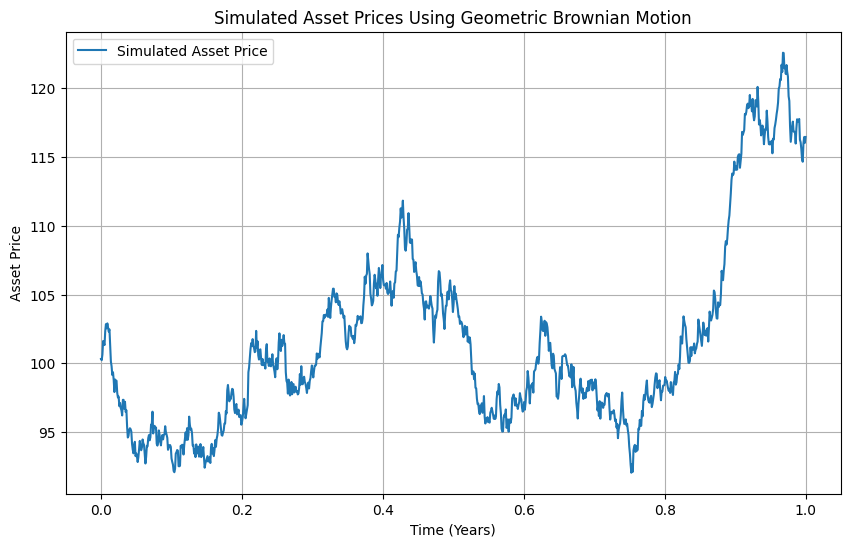

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters for the GBM model
S0 = 100  # initial asset price
mu = 0.05  # drift (expected return)
sigma = 0.2  # volatility
T = 1.0  # time horizon (in years)
N = 1000  # number of time steps
dt = T / N  # time step
np.random.seed(42)  # for reproducibility

# Simulating the asset price paths
t = np.linspace(0, T, N)
W = np.random.standard_normal(size=N)  # Wiener process increments
W = np.cumsum(W) * np.sqrt(dt)  # cumulative sum to simulate the random walk
S = S0 * np.exp((mu - 0.5 * sigma**2) * t + sigma * W)  # GBM formula

# Plotting the simulated asset price path
plt.figure(figsize=(10, 6))
plt.plot(t, S, label="Simulated Asset Price")
plt.title('Simulated Asset Prices Using Geometric Brownian Motion')
plt.xlabel('Time (Years)')
plt.ylabel('Asset Price')
plt.grid(True)
plt.legend()
plt.show()

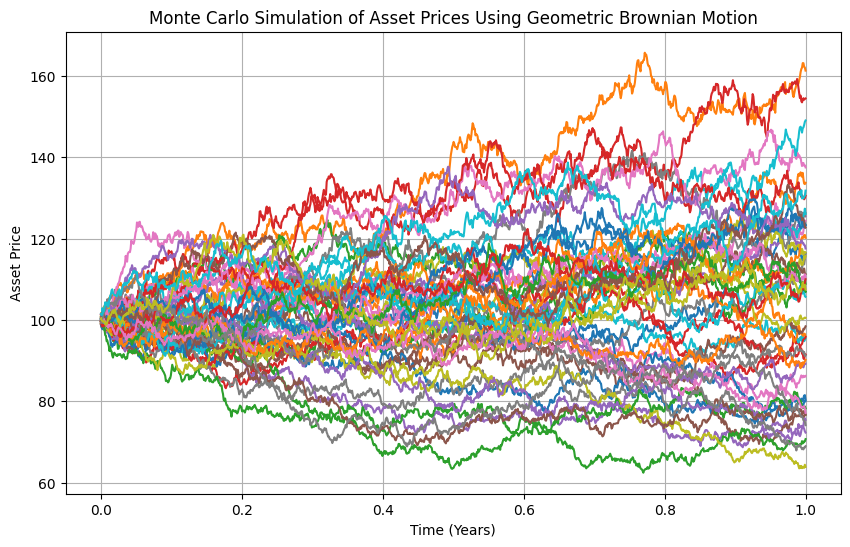

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters for the GBM model
S0 = 100  # initial asset price
mu = 0.05  # drift (expected return)
sigma = 0.2  # volatility
T = 1.0  # time horizon (in years)
N = 1000  # number of time steps
M = 50  # number of simulations
dt = T / N  # time step
np.random.seed(42)  # for reproducibility

# Simulating M paths of the asset price
t = np.linspace(0, T, N)  # time array
S = np.zeros((M, N))  # matrix to store asset prices
S[:, 0] = S0  # initial price for all simulations

# Simulate each path using the GBM model
for i in range(M):
    W = np.random.standard_normal(size=N)  # Wiener process increments
    W = np.cumsum(W) * np.sqrt(dt)  # cumulative sum for Wiener process
    S[i, :] = S0 * np.exp((mu - 0.5 * sigma**2) * t + sigma * W)  # GBM formula

# Plotting the Monte Carlo simulated asset price paths
plt.figure(figsize=(10, 6))
for i in range(M):
    plt.plot(t, S[i, :], lw=1.5)
plt.title('Monte Carlo Simulation of Asset Prices Using Geometric Brownian Motion')
plt.xlabel('Time (Years)')
plt.ylabel('Asset Price')
plt.grid(True)
plt.show()

In [10]:
import numpy as np
import pandas as pd
import pandas_datareader as pdr
import pandas_datareader.data as web
import yfinance as yf
import datetime as dt
import matplotlib.pyplot as plt

from matplotlib import style
plt.rcParams["figure.figsize"] = (20,10)

In [11]:
# Set start and end dates
start = dt.datetime(2018, 1, 1)
end = dt.datetime.now()

# Download the data
df = yf.download('TSLA', start, end)

[*********************100%***********************]  1 of 1 completed


In [12]:
df

Price,Close,High,Low,Open,Volume
Ticker,TSLA,TSLA,TSLA,TSLA,TSLA
Date,,,,,
2018-01-02,21.368668,21.474001,20.733334,20.799999,65283000
2018-01-03,21.150000,21.683332,21.036667,21.400000,67822500
2018-01-04,20.974667,21.236668,20.378668,20.858000,149194500
2018-01-05,21.105333,21.149332,20.799999,21.108000,68868000
2018-01-08,22.427334,22.468000,21.033333,21.066668,147891000
...,...,...,...,...,...
2025-06-23,348.679993,357.540009,327.480011,327.540009,190716800
2025-06-24,340.470001,356.260010,340.440002,356.170013,114736200


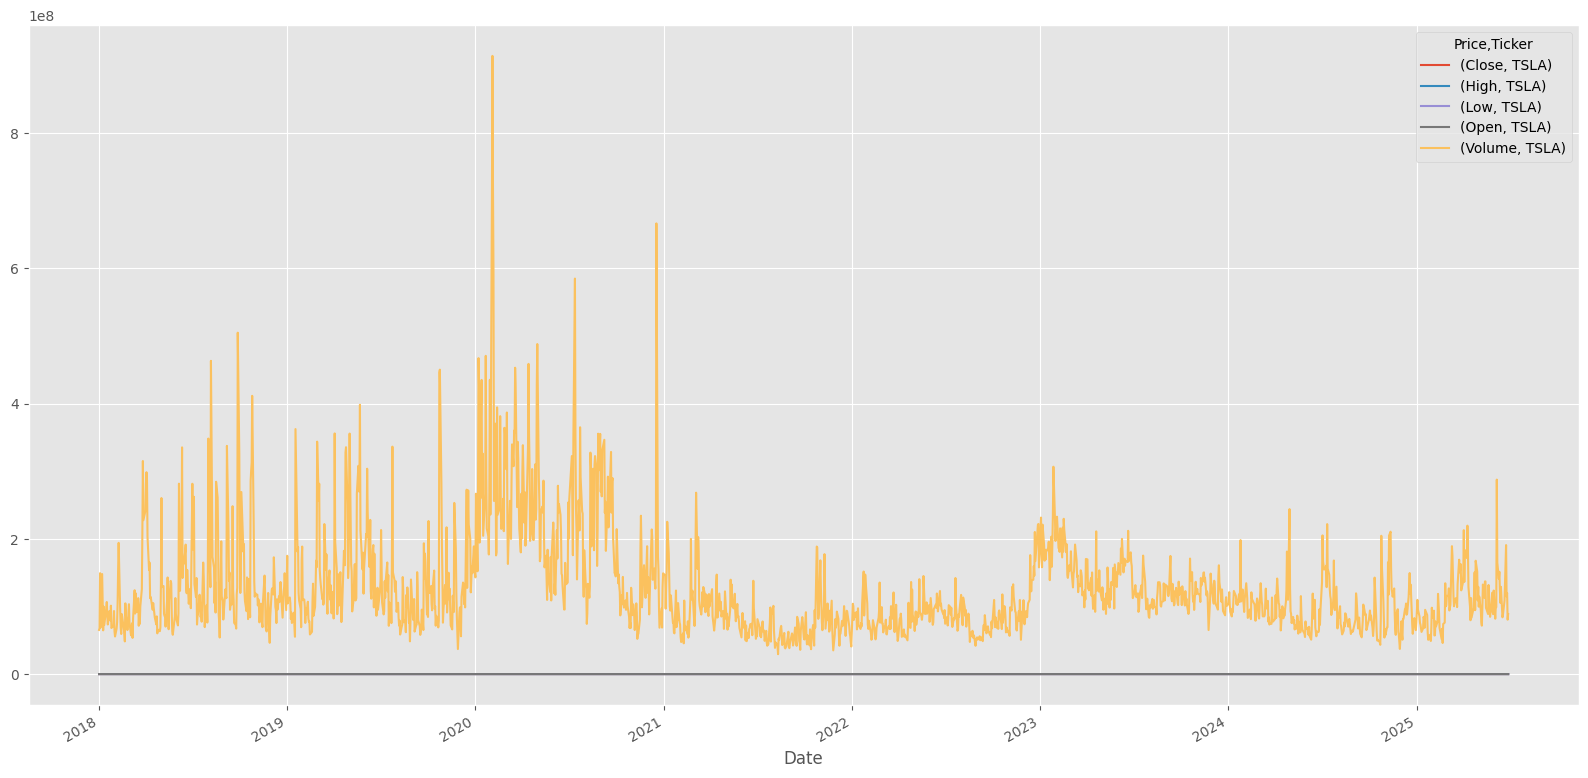

In [13]:
style.use('ggplot')
df.plot()
plt.show()

In [18]:
! pip install ccxt


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.6/5.6 MB 44.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10/10 [ccxt]2m 9/10 [ccxt]


In [19]:
import ccxt
print (ccxt.exchanges)


['alpaca', 'apex', 'ascendex', 'bequant', 'bigone', 'binance', 'binancecoinm', 'binanceus', 'binanceusdm', 'bingx', 'bit2c', 'bitbank', 'bitbns', 'bitfinex', 'bitflyer', 'bitget', 'bithumb', 'bitmart', 'bitmex', 'bitopro', 'bitrue', 'bitso', 'bitstamp', 'bitteam', 'bittrade', 'bitvavo', 'blockchaincom', 'blofin', 'btcalpha', 'btcbox', 'btcmarkets', 'btcturk', 'bybit', 'cex', 'coinbase', 'coinbaseadvanced', 'coinbaseexchange', 'coinbaseinternational', 'coincatch', 'coincheck', 'coinex', 'coinmate', 'coinmetro', 'coinone', 'coinsph', 'coinspot', 'cryptocom', 'cryptomus', 'defx', 'delta', 'deribit', 'derive', 'digifinex', 'ellipx', 'exmo', 'fmfwio', 'gate', 'gateio', 'gemini', 'hashkey', 'hitbtc', 'hollaex', 'htx', 'huobi', 'hyperliquid', 'independentreserve', 'indodax', 'kraken', 'krakenfutures', 'kucoin', 'kucoinfutures', 'latoken', 'lbank', 'luno', 'mercado', 'mexc', 'modetrade', 'myokx', 'ndax', 'novadax', 'oceanex', 'okcoin', 'okx', 'okxus', 'onetrading', 'oxfun', 'p2b', 'paradex', '

In [21]:
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt